In [5]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.convolution import convolve, Gaussian1DKernel
from sklearn.decomposition import PCA
from sparcl.client import SparclClient
from dl import queryClient as qc

print("TODO FUNCIONA")

TODO FUNCIONA


In [6]:
# Instanciamos el cliente SPARCL, El read_timeout=300 y tambien el connect ayuda a que no falle tan rápido si el servidor tarda.
client = SparclClient(connect_timeout=30,read_timeout=300)

announcement=Data set deprecation notice: on November 19, 2025 the SDSS/BOSS DR16 data sets were deprecated. Please use the new SDSS/BOSS DR17 data sets instead.


In [7]:
 #Consulta de quásares DESI,busca quásares (QSO) de DESI DR tomado el 0.1% , de la encuesta principal, usando solo el espectro primario. 
#Obtiene el targetid y el redshift z
query = """
        SELECT zp.targetid, zp.z
        FROM desi_dr1.zpix AS zp
        WHERE (zp.survey='main') AND (zp.spectype ='QSO') AND zp.main_primary AND (zp.random_id BETWEEN 0.0 AND 0.1)
        """ 
zpix_cat = qc.query(sql = query, fmt = 'table')
targetid = [int(x) for x in zpix_cat['targetid'].data.tolist()]
z_qso = np.array(zpix_cat['z'].data.tolist(), dtype=float)

print("Número total de quásares:", len(targetid))
print(zpix_cat[:5])


Número total de quásares: 1721
     targetid             z        
----------------- -----------------
39627751036029644 2.240708255153232
39628033765676308 2.361188543850257
39627980468654898 2.516868132018854
39627845382705283 2.578377403839813
39627805423570435 1.195947426767599


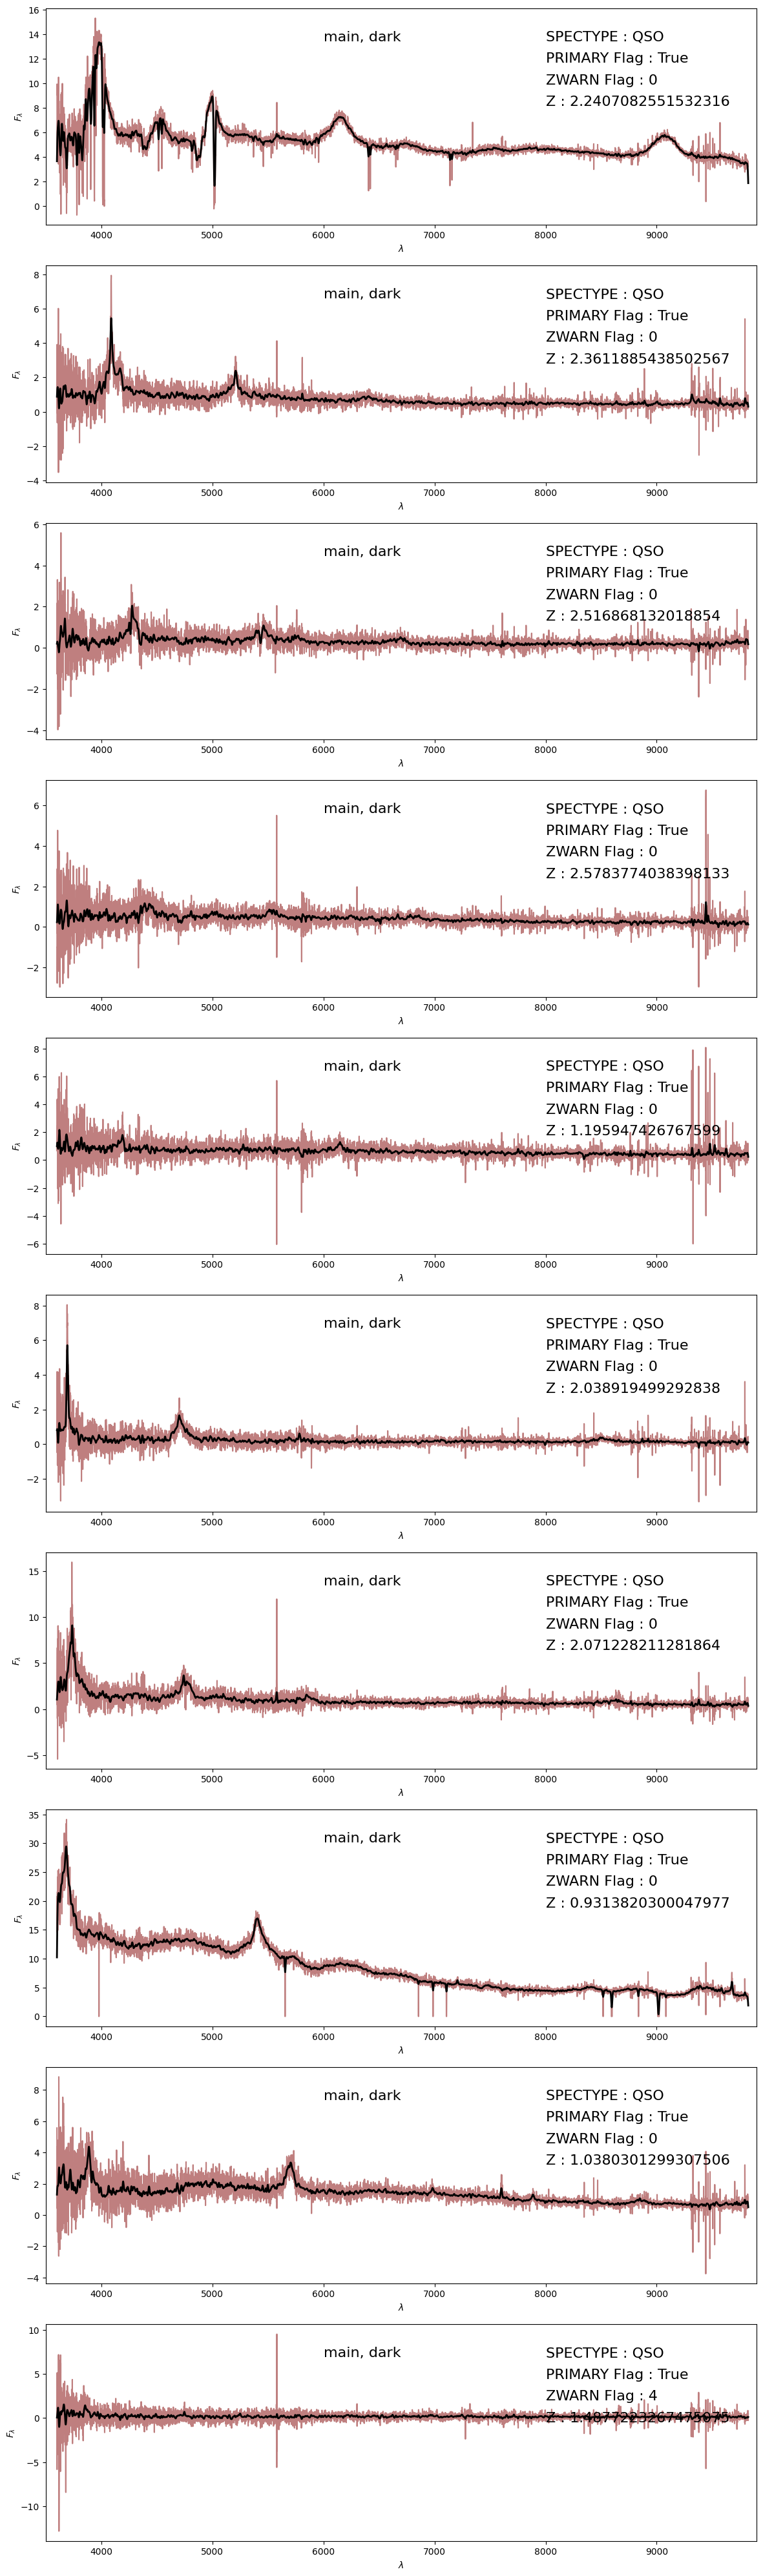

In [8]:
# Graficamos los espectros

n =10 #len(targetid)

fig, ax = plt.subplots(n, 1, figsize = (12,(4*n)))

for jj in range(n):
    inc = ['specid', 'redshift', 'flux', 'wavelength', 'spectype', 'specprimary', 'survey', 'program', 'targetid', 'redshift_warning']
    res = client.retrieve_by_specid(specid_list = [targetid[jj]],
                                include = inc,
                                dataset_list = ['DESI-DR1'])
    records = res.records
    survey = records[0].survey
    program = records[0].program
    spectype = records[0].spectype
    primary_flag = records[0].specprimary
    zwarn_flag = records[0].redshift_warning
    redshift = records[0].redshift

    lam = records[0].wavelength
    flam = records[0].flux
    
    # Plot the combined spectrum in maroon
    ax[jj].plot(lam, flam, color = 'maroon', alpha = 0.5)
    # Over-plotting smoothed spectra 
    ax[jj].plot(lam, convolve(flam, Gaussian1DKernel(5)), color = 'k', lw = 2.0)
    ax[jj].set(xlim = [3500, 9900], xlabel = r'$\lambda$', ylabel = r'$F_{\lambda}$')
    trans = ax[jj].get_xaxis_transform()
    ax[jj].annotate(f'{survey}, {program}', xy = (6000, 0.85), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'SPECTYPE : {spectype}', xy = (8000, 0.85), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'PRIMARY Flag : {primary_flag}', xy = (8000, 0.75), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'ZWARN Flag : {zwarn_flag}', xy = (8000, 0.65), xycoords = trans, fontsize = 16)
    ax[jj].annotate(f'Z : {redshift }', xy = (8000, 0.55), xycoords = trans, fontsize = 16)
    
plt.tight_layout()


In [10]:
#Separamos Quasares por redshift on z<2 y z>2 muestran regiones espectrales distintas dentro del rango observado por DESI
mask_lowz = z_qso < 2.0
mask_highz = z_qso >= 2.0

targetid_lowz = np.array(targetid)[mask_lowz]
z_lowz = z_qso[mask_lowz]

targetid_highz = np.array(targetid)[mask_highz]
z_highz = z_qso[mask_highz]

print("Quásares con z < 2:", len(targetid_lowz))
print("Quásares con z >= 2:", len(targetid_highz))

Quásares con z < 2: 1154
Quásares con z >= 2: 567


In [23]:
#Definimos las  mallas en marco de reposo, aqui pondremos todos los espectros ya que para el PCA todos los espectros deben tener el mismo eje .
# para z>2 
#3600 <λ_obs<9800  y cuando conviertes a reposo:
#λ_rest=1 + z/λ_obs, entonces si Z=2
# 3600/3= 1200 y 9800/3=3267
# Y para z<2, usamos lo que resta 

lambda_rest_lowz = np.linspace(2600, 4100, 2200)
lambda_rest_highz = np.linspace(1200, 3200, 2500)

In [24]:
#Hacemos una grafica como control para observar los espectros y verificar que el espectro si se esta moviendo bien al marco de reposo, 
#y ver la zona que usaremos para el PCA, es decir la malla
def graficar_control_target(targetid_obj, lambda_rest_grid):

    inc = [
        'flux',
        'wavelength',
        'redshift',
        'spectype',
        'specprimary',
        'survey',
        'program',
        'targetid',
        'redshift_warning'
    ]

    res = client.retrieve_by_specid(
        specid_list=[int(targetid_obj)],
        include=inc,
        dataset_list=['DESI-DR1']
    )

    record = res.records[0]

    lam_obs = np.array(record.wavelength)
    flux = np.array(record.flux)
    z = record.redshift

    lam_rest = lam_obs / (1 + z)
    flux_smooth = convolve(flux, Gaussian1DKernel(5))

    fig, ax = plt.subplots(2, 1, figsize=(12, 7))

    ax[0].plot(lam_obs, flux, color="maroon", alpha=0.4)
    ax[0].plot(lam_obs, flux_smooth, color="black", lw=2)
    ax[0].set_xlabel(r"$\lambda_{\rm obs}$ [$\AA$]")
    ax[0].set_ylabel(r"$F_\lambda$")
    ax[0].set_title("Espectro observado")

    ax[1].plot(lam_rest, flux, color="maroon", alpha=0.4)
    ax[1].plot(lam_rest, flux_smooth, color="black", lw=2)

    ax[1].axvspan(
        lambda_rest_grid.min(),
        lambda_rest_grid.max(),
        color="gray",
        alpha=0.2,
        label="Ventana PCA"
    )

    ax[1].set_xlim(lambda_rest_grid.min() - 300, lambda_rest_grid.max() + 300)
    ax[1].set_xlabel(r"$\lambda_{\rm rest}$ [$\AA$]")
    ax[1].set_ylabel(r"$F_\lambda$")
    ax[1].set_title("Espectro en marco de reposo")
    ax[1].legend()

    fig.suptitle(
        f"TARGETID={int(record.targetid)} | z={z:.3f} | "
        f"{record.survey}, {record.program} | "
        f"SPECTYPE={record.spectype} | ZWARN={record.redshift_warning}"
    )

    plt.tight_layout()
    plt.show()


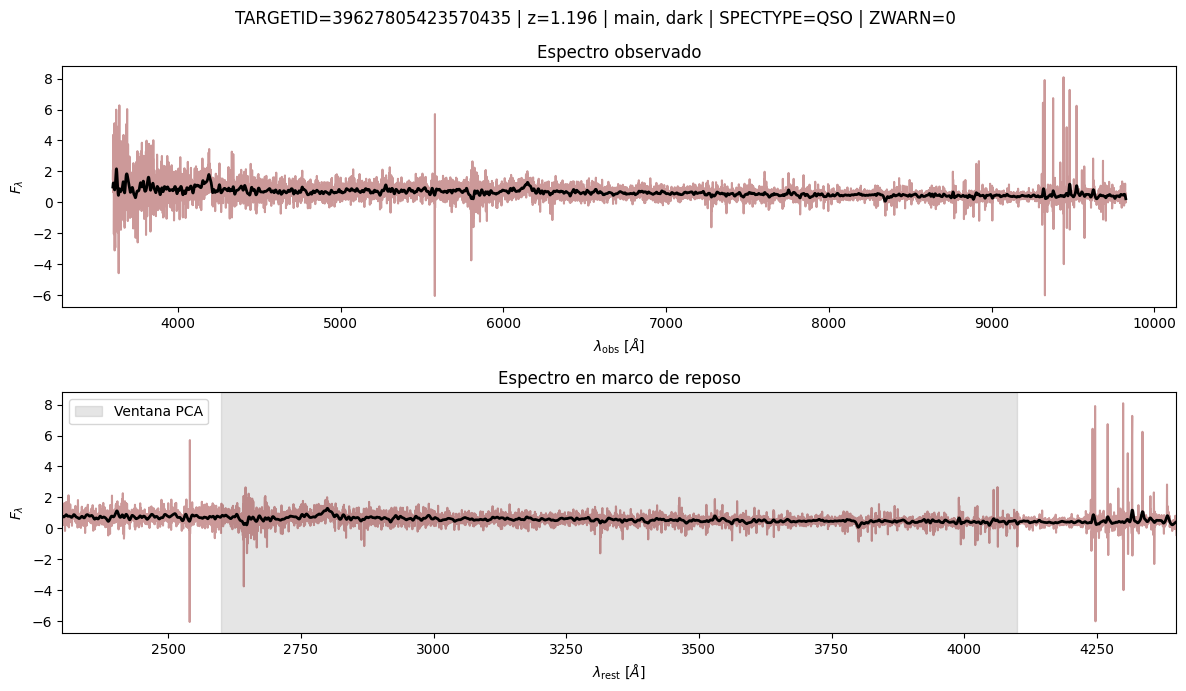

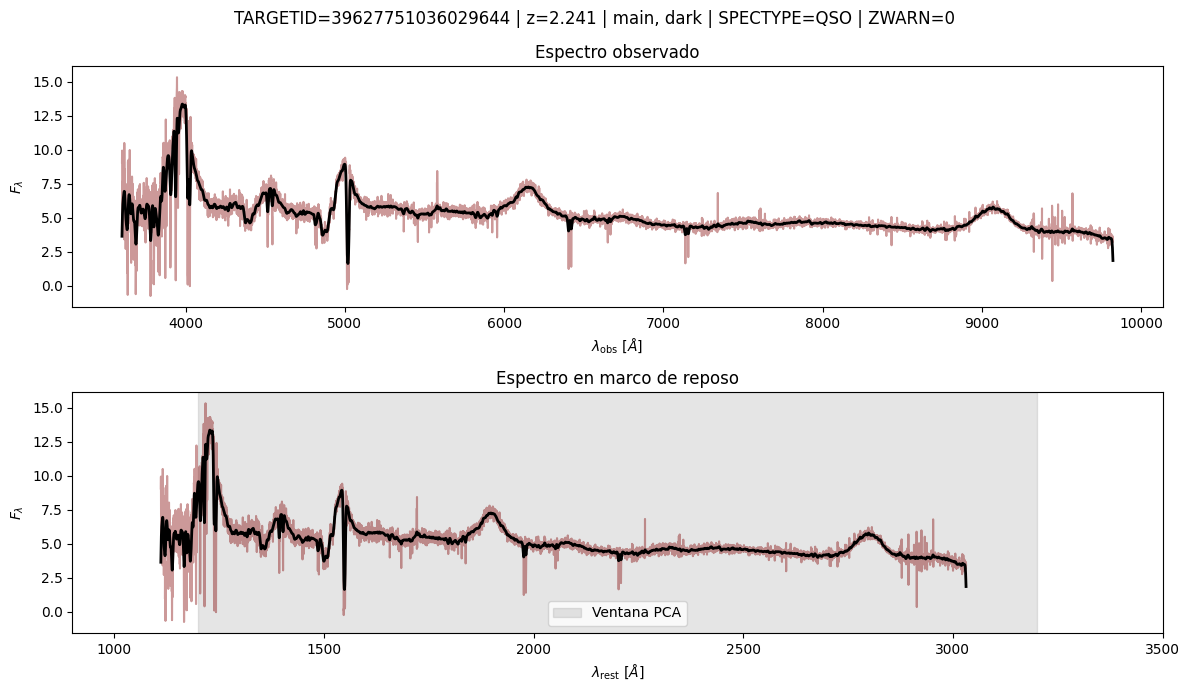

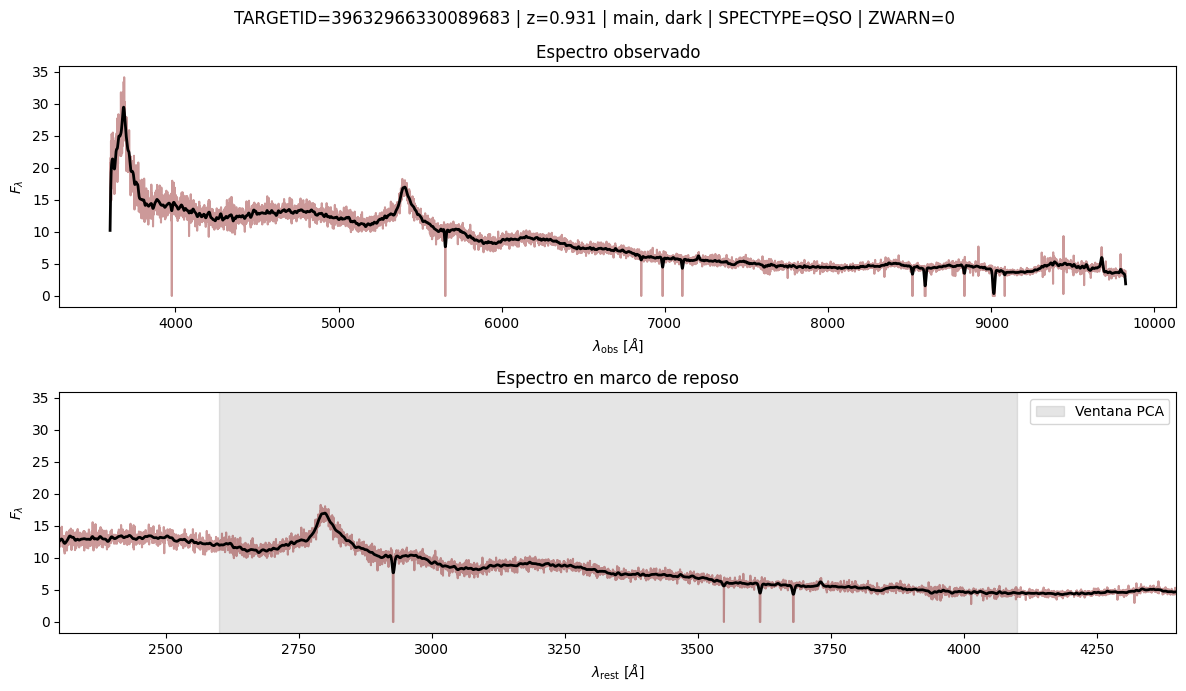

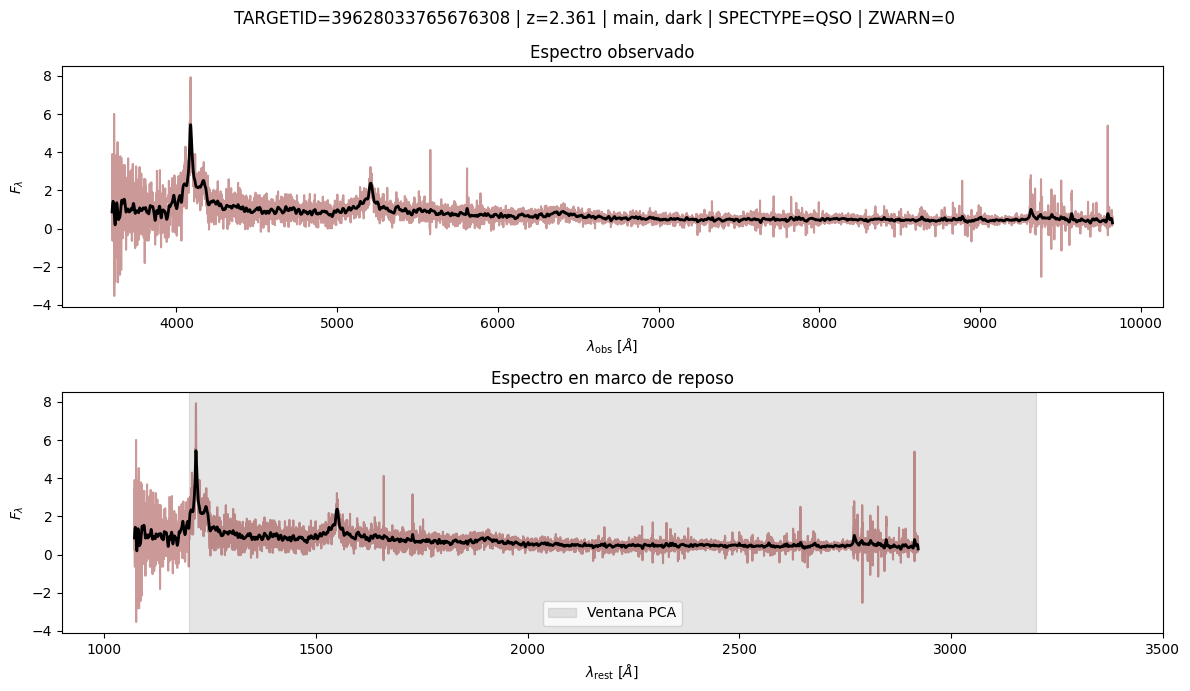

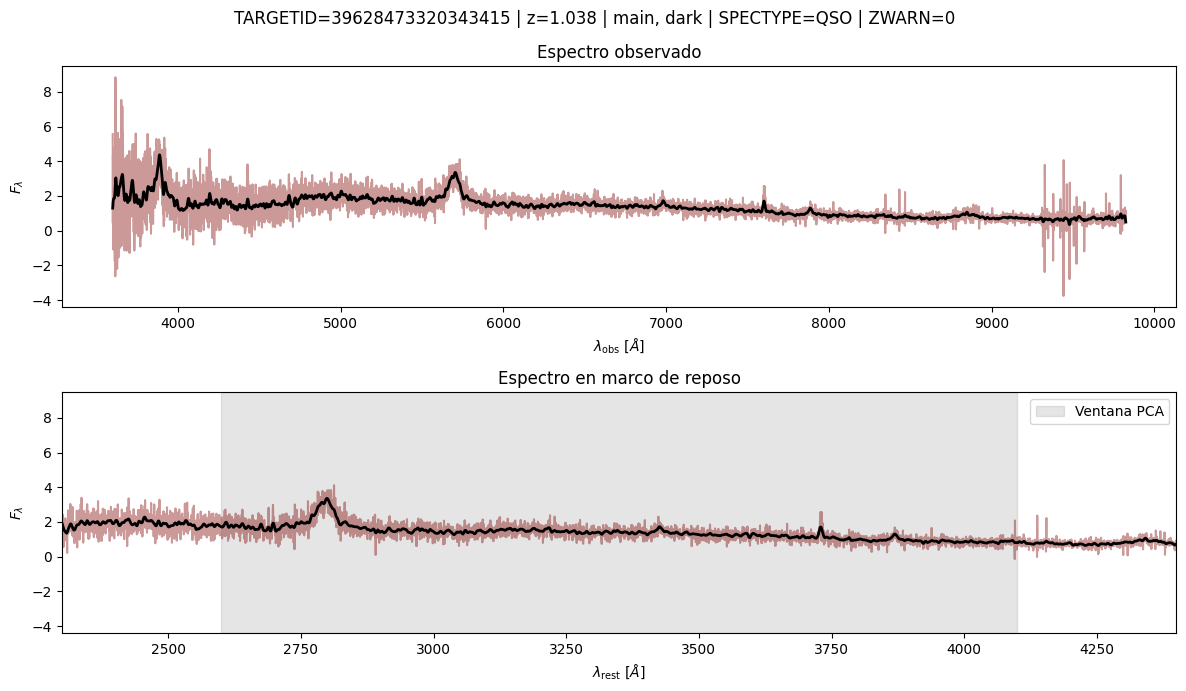

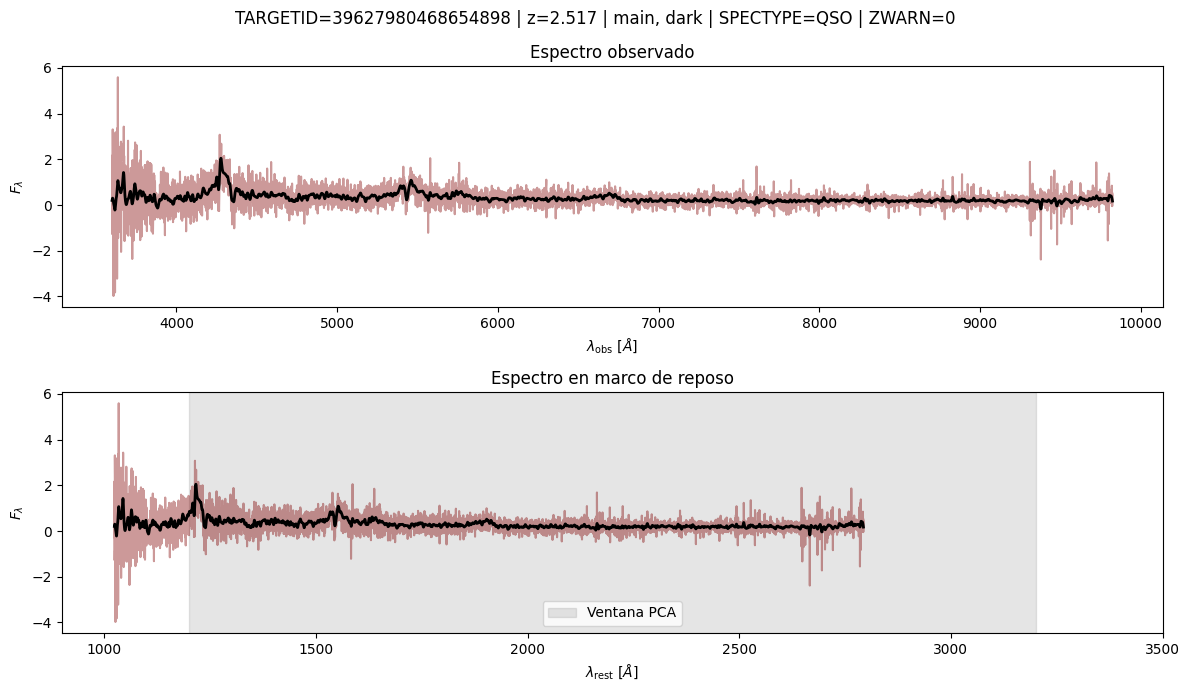

In [26]:
graficar_control_target(targetid_lowz[0], lambda_rest_lowz)
graficar_control_target(targetid_highz[0], lambda_rest_highz)
graficar_control_target(targetid_lowz[1], lambda_rest_lowz)
graficar_control_target(targetid_highz[1], lambda_rest_highz)
graficar_control_target(targetid_lowz[2], lambda_rest_lowz)
graficar_control_target(targetid_highz[2], lambda_rest_highz)

In [27]:
#Definimos la function para construir matriz espectral,pasa el espectro en reposo lo interpola a una 
#malla , lo normalizamos y construimos la matriz, esta es la matriz que va a entrar al PCA

def construir_matriz_DESI(targetids, redshifts, lambda_rest_grid, n_spec=30):

    X = []
    z_usados = []
    ids_usados = []

    inc = [
        'flux',
        'wavelength',
        'redshift',
        'spectype',
        'specprimary',
        'survey',
        'program',
        'targetid',
        'redshift_warning'
    ]

    for idx, tid in enumerate(targetids[:n_spec]):

        try:
            res = client.retrieve_by_specid(
                specid_list=[int(tid)],
                include=inc,
                dataset_list=['DESI-DR1']
            )

            record = res.records[0]

            if record.redshift_warning != 0:
                continue

            lam_obs = np.array(record.wavelength)
            flux = np.array(record.flux)
            z = record.redshift

            lam_rest = lam_obs / (1 + z)

            flux_smooth = convolve(
                flux,
                Gaussian1DKernel(5)
            )

            flux_interp = np.interp(
                lambda_rest_grid,
                lam_rest,
                flux_smooth,
                left=np.nan,
                right=np.nan
            )

            if np.sum(np.isfinite(flux_interp)) < 0.8 * len(lambda_rest_grid):
                continue

            med = np.nanmedian(flux_interp)

            if med == 0 or not np.isfinite(med):
                continue

            flux_interp = flux_interp / med
            flux_interp = np.nan_to_num(flux_interp, nan=0.0)

            X.append(flux_interp)
            z_usados.append(z)
            ids_usados.append(int(tid))

            print(f"Descargado {len(X)} espectros")

        except Exception as e:
            print(f"Falló targetid {tid}: {e}")

    return np.array(X), np.array(z_usados), np.array(ids_usados)

In [28]:
#Ahora construimos dos matrices:una para quásares con z<2, otra para z≥2, 
#donde cada fila es un espectro y cada columna una longitud de onda

X_lowz, z_lowz_used, ids_lowz_used = construir_matriz_DESI(
    targetid_lowz,
    z_lowz,
    lambda_rest_lowz,
    n_spec=30
)

X_highz, z_highz_used, ids_highz_used = construir_matriz_DESI(
    targetid_highz,
    z_highz,
    lambda_rest_highz,
    n_spec=30
)

print("X_lowz:", X_lowz.shape)
print("X_highz:", X_highz.shape)


Descargado 1 espectros
Descargado 2 espectros
Descargado 3 espectros
Falló targetid 39627580705345535: HTTPSConnectionPool(host='astrosparcl.datalab.noirlab.edu', port=443): Max retries exceeded with url: /api/find/?limit=500 (Caused by ConnectTimeoutError(<HTTPSConnection(host='astrosparcl.datalab.noirlab.edu', port=443) at 0x1daa06b9fd0>, 'Connection to astrosparcl.datalab.noirlab.edu timed out. (connect timeout=3.1)'))
Descargado 4 espectros
Descargado 5 espectros
Descargado 6 espectros
Descargado 7 espectros
Descargado 8 espectros
Falló targetid 39627872901531250: [UNKSPARC] ConnectTimeout: HTTPSConnectionPool(host='astrosparcl.datalab.noirlab.edu', port=443): Max retries exceeded with url: /api/spectras/?include=sparcl_id%2Cprogram%2Cspectype%2Cflux%2Cspecprimary%2Ctargetid%2Credshift_warning%2Csurvey%2Cwavelength%2Credshift%2Cspecid&format=pkl&dataset_list=DESI-DR1 (Caused by ConnectTimeoutError(<HTTPSConnection(host='astrosparcl.datalab.noirlab.edu', port=443) at 0x1daa0683150>,

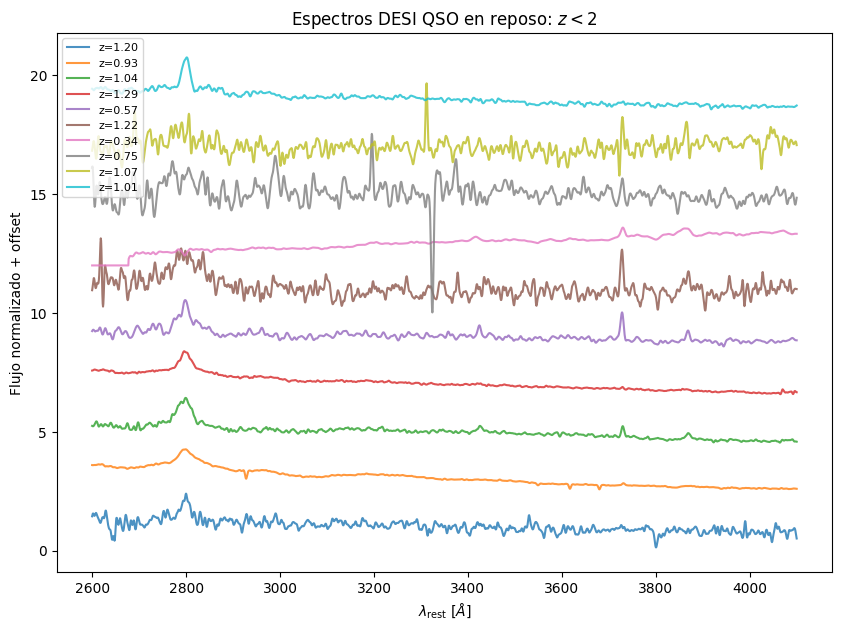

In [29]:
#Volvemos a graficar pero ahora los espectros ya en reposo, solo para ver otra vez como quedaron  
#si las líneas ya están alineadas en el marco de reposo
plt.figure(figsize=(10, 7))

for i in range(min(10, X_lowz.shape[0])):
    plt.plot(
        lambda_rest_lowz,
        X_lowz[i] + 2*i,
        alpha=0.8,
        label=f"z={z_lowz_used[i]:.2f}"
    )

plt.xlabel(r"$\lambda_{\rm rest}$ [$\AA$]")
plt.ylabel("Flujo normalizado + offset")
plt.title(r"Espectros DESI QSO en reposo: $z<2$")
plt.legend(fontsize=8)
plt.show()

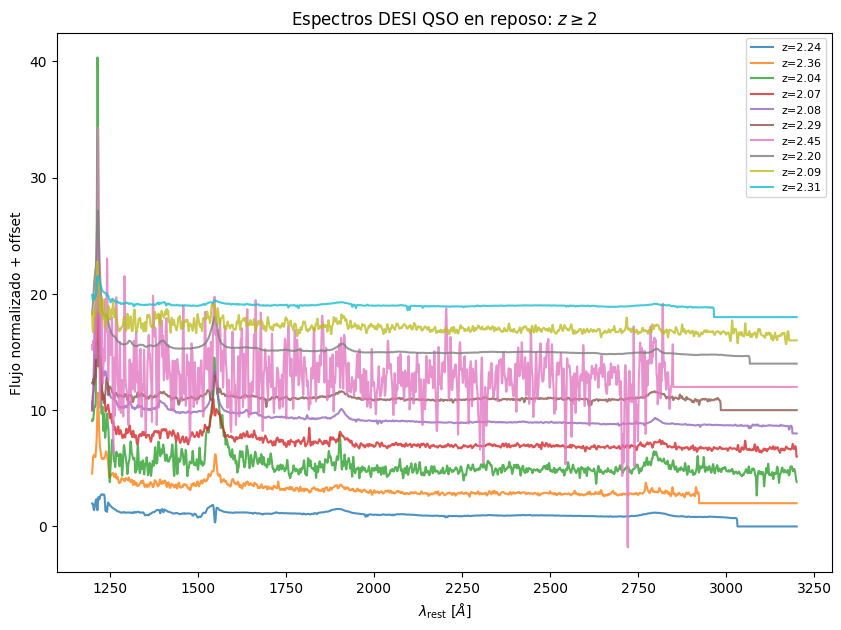

In [30]:
plt.figure(figsize=(10, 7))

for i in range(min(10, X_highz.shape[0])):
    plt.plot(
        lambda_rest_highz,
        X_highz[i] + 2*i,
        alpha=0.8,
        label=f"z={z_highz_used[i]:.2f}"
    )

plt.xlabel(r"$\lambda_{\rm rest}$ [$\AA$]")
plt.ylabel("Flujo normalizado + offset")
plt.title(r"Espectros DESI QSO en reposo: $z\geq2$")
plt.legend(fontsize=8)
plt.show()

In [32]:
#Ahora ya toca aplicar el PCA, aplicamos PCA a cada grupo por separado y obtenemos eigenvalues, 
#eigenvectores, varianza acumulada y el espectro promedio.
pca_lowz = PCA()
pca_lowz.fit(X_lowz)

pca_highz = PCA()
pca_highz.fit(X_highz)

evals_lowz = pca_lowz.explained_variance_ratio_
evals_highz = pca_highz.explained_variance_ratio_

evals_cs_lowz = evals_lowz.cumsum()
evals_cs_highz = evals_highz.cumsum()

evecs_lowz = pca_lowz.components_
evecs_highz = pca_highz.components_

spec_mean_lowz = pca_lowz.mean_
spec_mean_highz = pca_highz.mean_

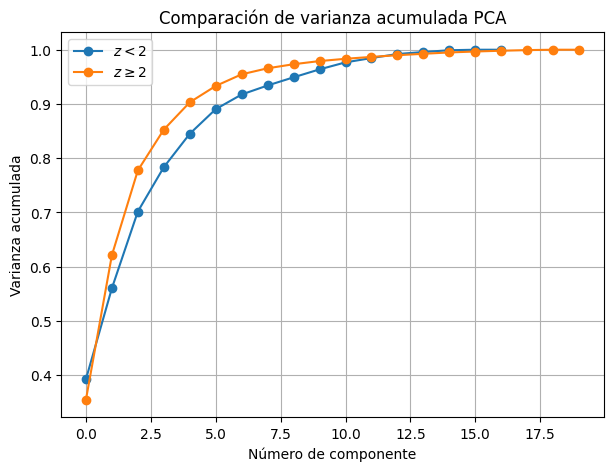

In [33]:
#Explicamos la varianza , graficamos y nos dira cuantas componentes necesitamos para reconstruir la mayor parte de informacion
plt.figure(figsize=(7, 5))

plt.plot(evals_cs_lowz, "o-", label=r"$z<2$")
plt.plot(evals_cs_highz, "o-", label=r"$z\geq2$")

plt.xlabel("Número de componente")
plt.ylabel("Varianza acumulada")
plt.title("Comparación de varianza acumulada PCA")
plt.legend()
plt.grid()
plt.show()

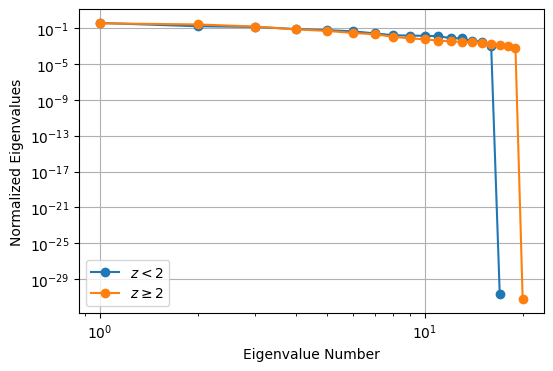

In [37]:
#Graficamos los eigenvalores
fig = plt.figure(figsize=(6, 4))

fig.subplots_adjust(
    bottom=0.12
)

ax = fig.add_subplot(
    111,
    xscale='log',
    yscale='log'
)

ax.grid()

ax.plot(
    n_lowz,
    evals_lowz,
    'o-',
    label=r'$z<2$'
)

ax.plot(
    n_highz,
    evals_highz,
    'o-',
    label=r'$z\geq2$'
)

ax.set_xlabel('Eigenvalue Number')

ax.set_ylabel('Normalized Eigenvalues')

ax.legend()

plt.show()


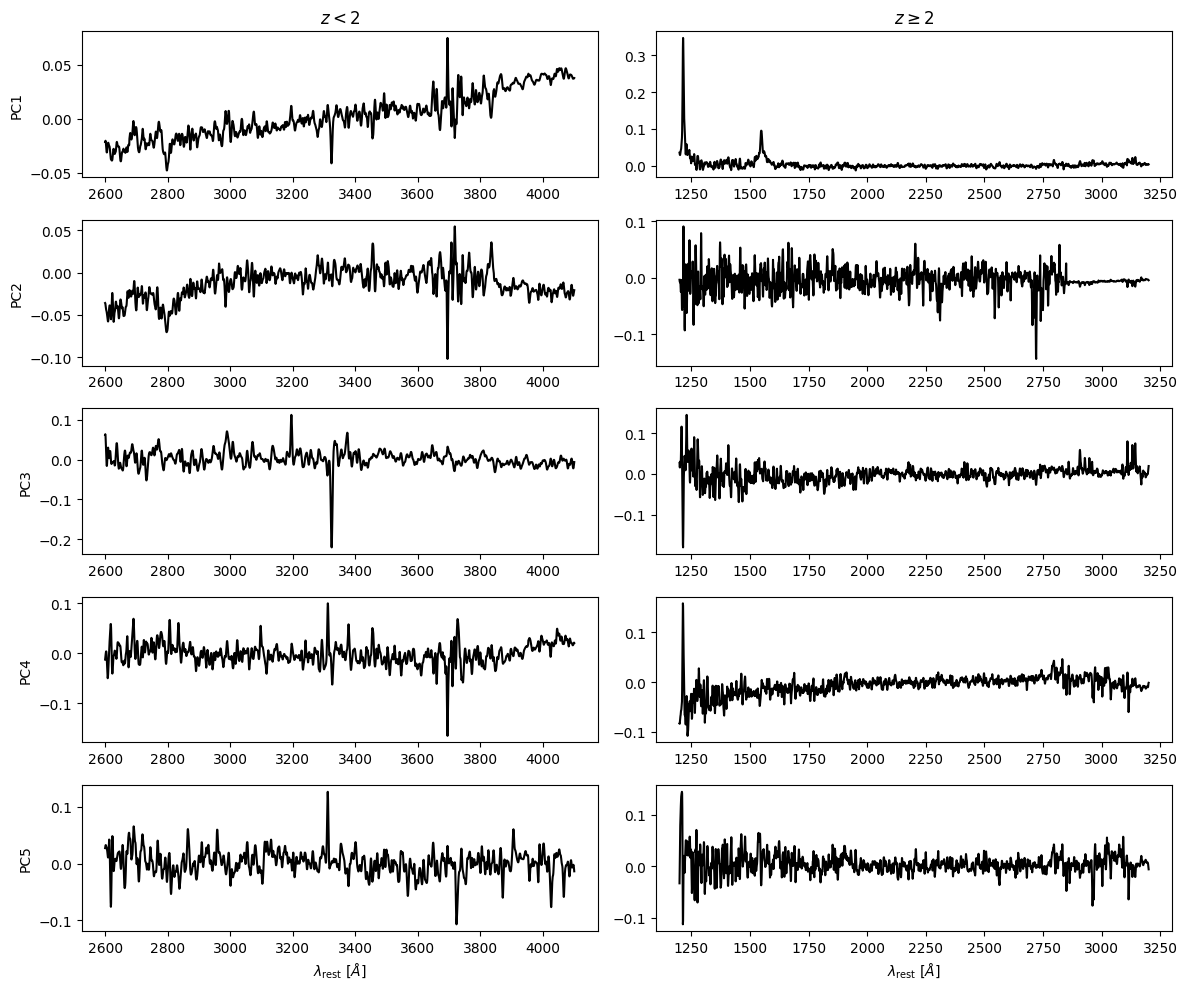

In [34]:
#Ahora veamos los eigenvectores
fig, ax = plt.subplots(5, 2, figsize=(12, 10), sharex=False)

for i in range(5):

    ax[i, 0].plot(lambda_rest_lowz, evecs_lowz[i], color="black")
    ax[i, 0].set_ylabel(f"PC{i+1}")

    if i == 0:
        ax[i, 0].set_title(r"$z<2$")

    ax[i, 1].plot(lambda_rest_highz, evecs_highz[i], color="black")

    if i == 0:
        ax[i, 1].set_title(r"$z\geq2$")

ax[-1, 0].set_xlabel(r"$\lambda_{\rm rest}$ [$\AA$]")
ax[-1, 1].set_xlabel(r"$\lambda_{\rm rest}$ [$\AA$]")

plt.tight_layout()
plt.show()

In [40]:
#Ahora rencosntruimos para cada grupo
def graficar_reconstruccion(X, lambda_grid, pca, idx=0, titulo=""):

    spec = X[idx]
    evecs = pca.components_
    spec_mean = pca.mean_
    evals_cs = pca.explained_variance_ratio_.cumsum()

    coeff = np.dot(evecs, spec - spec_mean)

    fig, ax = plt.subplots(4, 1, figsize=(9, 8), sharex=True)

    for i, n in enumerate([0, 2, 5, 10]):

        rec = spec_mean + np.dot(coeff[:n], evecs[:n])

        ax[i].plot(lambda_grid, spec, color='gray', label="Original")
        ax[i].plot(lambda_grid, rec, color='k', label="Reconstruido")

        if n == 0:
            text = "mean"
        else:
            text = f"mean + {n} comp.\nvar = {evals_cs[n-1]:.2f}"

        ax[i].text(0.03, 0.82, text, transform=ax[i].transAxes)
        ax[i].set_ylabel("Flujo")

    ax[-1].set_xlabel(r"$\lambda_{\rm rest}$ [$\AA$]")
    fig.suptitle(titulo)

    plt.tight_layout()
    plt.show()

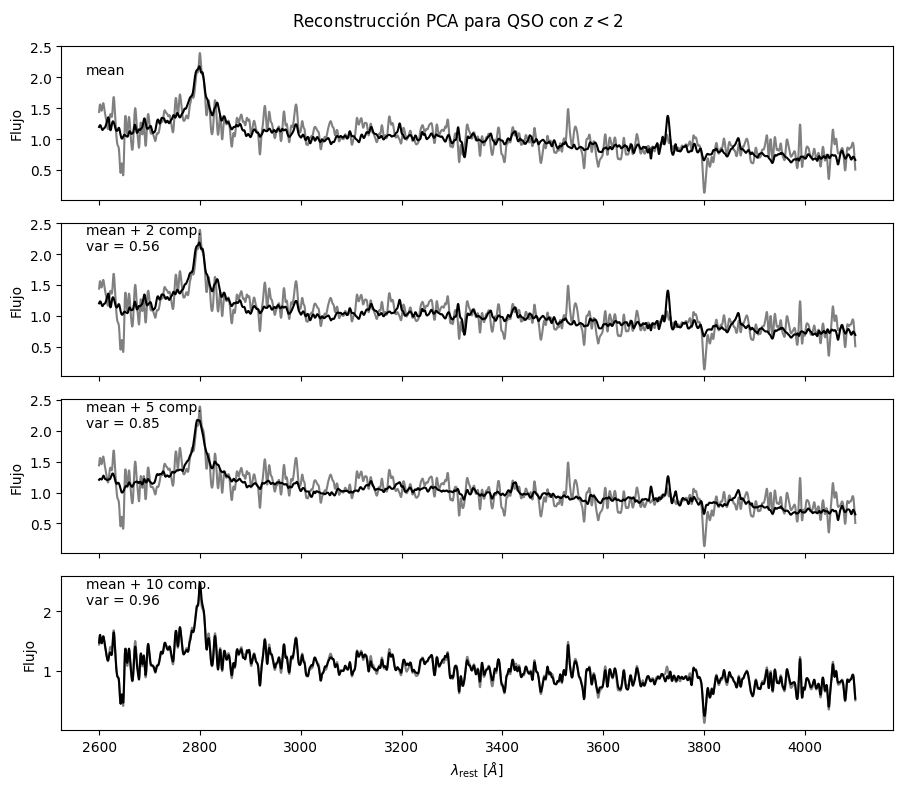

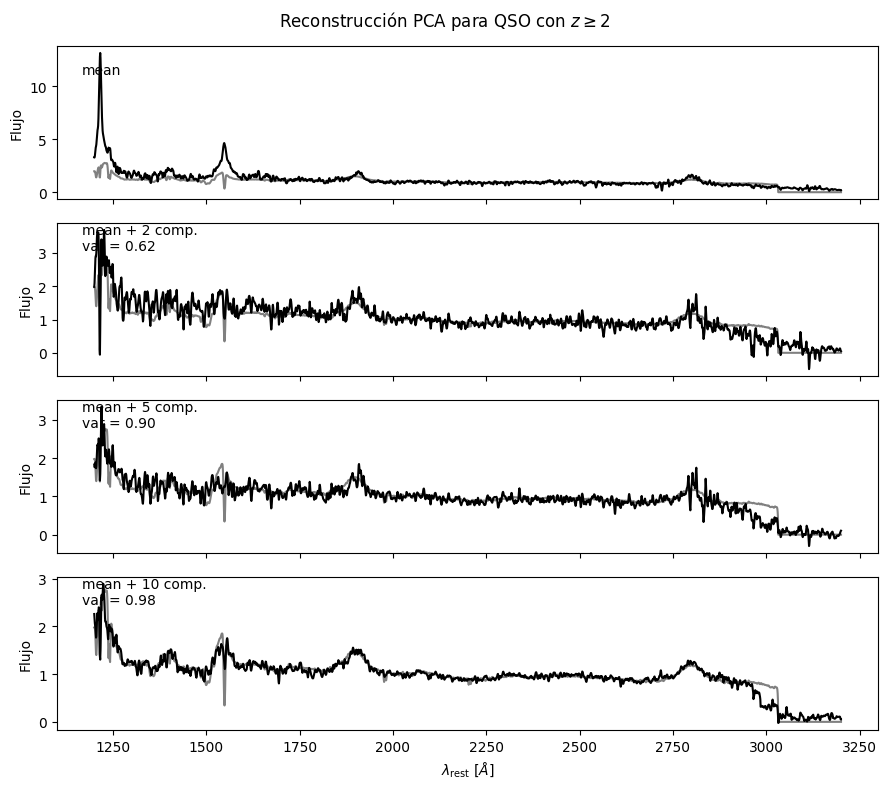

In [41]:
graficar_reconstruccion(
    X_lowz,
    lambda_rest_lowz,
    pca_lowz,
    idx=0,
    titulo=r"Reconstrucción PCA para QSO con $z<2$"
)

graficar_reconstruccion(
    X_highz,
    lambda_rest_highz,
    pca_highz,
    idx=0,
    titulo=r"Reconstrucción PCA para QSO con $z\geq2$"
)